In [2]:
import pandas as pd
import numpy as np

# Change these to your actual file names / paths
SENTIMENT_PATH = "fear_greed_index.csv"
TRADES_PATH    = "historical_data.csv"   # or trader_data.csv / .json-as-csv

sentiment = pd.read_csv(SENTIMENT_PATH)
trades = pd.read_csv(TRADES_PATH)

sentiment.head(), trades.head()

(    timestamp  value classification        date
 0  1517463000     30           Fear  2018-02-01
 1  1517549400     15   Extreme Fear  2018-02-02
 2  1517635800     40           Fear  2018-02-03
 3  1517722200     24   Extreme Fear  2018-02-04
 4  1517808600     11   Extreme Fear  2018-02-05,
                                       Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY 

In [3]:
# Shapes
print("Sentiment shape (rows, cols):", sentiment.shape)
print("Trades shape (rows, cols):   ", trades.shape)

# Duplicates
print("\nDuplicate rows:")
print("Sentiment duplicates:", sentiment.duplicated().sum())
print("Trades duplicates:   ", trades.duplicated().sum())

# Missing values per column
print("\nMissing values per column — sentiment:")
print(sentiment.isna().sum())

print("\nMissing values per column — trades:")
print(trades.isna().sum())

Sentiment shape (rows, cols): (2644, 4)
Trades shape (rows, cols):    (211224, 16)

Duplicate rows:
Sentiment duplicates: 0
Trades duplicates:    0

Missing values per column — sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values per column — trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [4]:
overview = pd.DataFrame([
    {"dataset": "sentiment", "rows": sentiment.shape[0], "cols": sentiment.shape[1],
     "duplicates": sentiment.duplicated().sum()},
    {"dataset": "trades",    "rows": trades.shape[0],    "cols": trades.shape[1],
     "duplicates": trades.duplicated().sum()},
])
overview

,dataset,rows,cols,duplicates
0,sentiment,2644,4,0
1,trades,211224,16,0


In [5]:
# 1. Parse sentiment dates to datetime (daily)
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["date_dt"] = sentiment["date"].dt.normalize()  # strip time just in case

# 2. Standardize trade column names for easier handling
trades.columns = [c.strip().lower().replace(" ", "_") for c in trades.columns]

# 3. Parse trade timestamps and create daily date
trades["timestamp_ist_dt"] = pd.to_datetime(
    trades["timestamp_ist"],  # original column 'Timestamp IST'
    dayfirst=True,
    errors="coerce",
)
trades["trade_date"] = trades["timestamp_ist_dt"].dt.normalize()

print(trades[["timestamp_ist", "timestamp_ist_dt", "trade_date"]].head())

      timestamp_ist    timestamp_ist_dt trade_date
0  02-12-2024 22:50 2024-12-02 22:50:00 2024-12-02
1  02-12-2024 22:50 2024-12-02 22:50:00 2024-12-02
2  02-12-2024 22:50 2024-12-02 22:50:00 2024-12-02
3  02-12-2024 22:50 2024-12-02 22:50:00 2024-12-02
4  02-12-2024 22:50 2024-12-02 22:50:00 2024-12-02


In [6]:
def map_sentiment(cls: str) -> str:
    cls_lower = str(cls).lower()
    if "fear" in cls_lower:
        return "Fear"
    if "greed" in cls_lower:
        return "Greed"
    return "Neutral"

sentiment["sentiment_group"] = sentiment["classification"].map(map_sentiment)

sentiment[["date_dt", "classification", "sentiment_group"]].head()

,date_dt,classification,sentiment_group
0,2018-02-01,Fear,Fear
1,2018-02-02,Extreme Fear,Fear
2,2018-02-03,Fear,Fear
3,2018-02-04,Extreme Fear,Fear
4,2018-02-05,Extreme Fear,Fear


In [7]:
merged = trades.merge(
    sentiment[["date_dt", "classification", "value", "sentiment_group"]],
    left_on="trade_date",
    right_on="date_dt",
    how="inner",   # or 'left' if you prefer to keep all trades
)

merged.shape, merged[["trade_date", "sentiment_group"]].head()

((211218, 22),
   trade_date sentiment_group
 0 2024-12-02           Greed
 1 2024-12-02           Greed
 2 2024-12-02           Greed
 3 2024-12-02           Greed
 4 2024-12-02           Greed)

In [8]:
merged["is_win"]  = merged["closed_pnl"] > 0
merged["is_loss"] = merged["closed_pnl"] < 0

In [9]:
daily_account = (
    merged
    .groupby(["trade_date", "account", "sentiment_group"], as_index=False)
    .agg(
        trades_count   = ("trade_id", "count"),   # number of trades that day
        pnl_sum        = ("closed_pnl", "sum"),   # total PnL that day
        pnl_mean       = ("closed_pnl", "mean"),  # avg PnL per trade that day
        wins           = ("is_win", "sum"),
        losses         = ("is_loss", "sum"),
        size_usd_sum   = ("size_usd", "sum"),     # total traded notional that day
        size_usd_mean  = ("size_usd", "mean"),    # avg trade size
    )
)

# Win rate per account-day (only where we have wins or losses)
non_zero_trades = daily_account["wins"] + daily_account["losses"]
daily_account["win_rate"] = daily_account["wins"] / non_zero_trades.replace({0: np.nan})

daily_account.head()

,trade_date,account,sentiment_group,trades_count,pnl_sum,pnl_mean,wins,losses,size_usd_sum,size_usd_mean,win_rate
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,3,0.000000,0.000000,0,0,477.00,159.000000,NaN
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,9,0.000000,0.000000,0,0,50005.83,5556.203333,NaN
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,11,-205.434737,-18.675885,4,2,113203.35,10291.213636,0.666667
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,2,-24.632034,-12.316017,0,2,10609.95,5304.975000,0.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,3,0.000000,0.000000,0,0,15348.77,5116.256667,NaN


In [10]:
daily_market = (
    merged
    .groupby(["trade_date", "sentiment_group"], as_index=False)
    .agg(
        trades_count     = ("trade_id", "count"),        # total trades that day
        accounts_active  = ("account", "nunique"),       # unique traders that day
        pnl_sum          = ("closed_pnl", "sum"),
        pnl_mean         = ("closed_pnl", "mean"),
        wins             = ("is_win", "sum"),
        losses           = ("is_loss", "sum"),
        size_usd_sum     = ("size_usd", "sum"),
        size_usd_mean    = ("size_usd", "mean"),
    )
)

daily_market.head()

,trade_date,sentiment_group,trades_count,accounts_active,pnl_sum,pnl_mean,wins,losses,size_usd_sum,size_usd_mean
0,2023-05-01,Greed,3,1,0.000000,0.000000,0,0,477.00,159.000000
1,2023-12-05,Greed,9,1,0.000000,0.000000,0,0,50005.83,5556.203333
2,2023-12-14,Greed,11,1,-205.434737,-18.675885,4,2,113203.35,10291.213636
3,2023-12-15,Greed,2,1,-24.632034,-12.316017,0,2,10609.95,5304.975000
4,2023-12-16,Greed,3,1,0.000000,0.000000,0,0,15348.77,5116.256667


In [11]:
# Focus on actual position opens for bias
mask_open_long  = merged["direction"].str.lower() == "open long"
mask_open_short = merged["direction"].str.lower() == "open short"

ls_daily = (
    merged
    .groupby(["trade_date", "sentiment_group"], as_index=False)
    .agg(
        open_long_count  = ("direction", lambda x: (x.str.lower() == "open long").sum()),
        open_short_count = ("direction", lambda x: (x.str.lower() == "open short").sum()),
    )
)

ls_daily["long_short_ratio"] = (
    ls_daily["open_long_count"] /
    ls_daily["open_short_count"].replace({0: np.nan})
)

ls_daily.head()

,trade_date,sentiment_group,open_long_count,open_short_count,long_short_ratio
0,2023-05-01,Greed,3,0,NaN
1,2023-12-05,Greed,7,2,3.5
2,2023-12-14,Greed,3,2,1.5
3,2023-12-15,Greed,0,0,NaN
4,2023-12-16,Greed,3,0,NaN


In [12]:
ls_by_sent = (
    merged
    .groupby("sentiment_group")
    .agg(
        open_long_count  = ("direction", lambda x: (x.str.lower() == "open long").sum()),
        open_short_count = ("direction", lambda x: (x.str.lower() == "open short").sum()),
    )
)
ls_by_sent["long_short_ratio"] = (
    ls_by_sent["open_long_count"] /
    ls_by_sent["open_short_count"].replace({0: np.nan})
)
ls_by_sent

,open_long_count,open_short_count,long_short_ratio
sentiment_group,,,
Fear,24829,14061,1.765806
Greed,14844,19327,0.768045
Neutral,10222,6353,1.609004


In [13]:
if "leverage" in merged.columns:
    print(merged["leverage"].describe())
    leverage_by_sent = merged.groupby("sentiment_group")["leverage"].describe()
    leverage_by_sent
else:
    print("No explicit 'Leverage' column found — consider using size / collateral as a proxy if available.")

No explicit 'Leverage' column found — consider using size / collateral as a proxy if available.


In [14]:
perf_by_sent = (
    daily_account
    .groupby("sentiment_group")
    .agg(
        account_days                = ("account", "count"),
        unique_accounts             = ("account", "nunique"),
        avg_trades_per_account_day  = ("trades_count", "mean"),
        avg_pnl_per_account_day     = ("pnl_sum", "mean"),
        median_pnl_per_account_day  = ("pnl_sum", "median"),
        avg_win_rate                = ("win_rate", "mean"),
    )
    .round(2)
)

perf_by_sent

,account_days,unique_accounts,avg_trades_per_account_day,avg_pnl_per_account_day,median_pnl_per_account_day,avg_win_rate
sentiment_group,,,,,,
Fear,790,32,105.36,5185.15,122.74,0.84
Greed,1174,31,76.91,4144.21,265.25,0.86
Neutral,376,31,100.23,3438.62,167.55,0.84


In [15]:
drawdown_proxy = (
    daily_account
    .groupby("sentiment_group")["pnl_sum"]
    .quantile([0.1, 0.25, 0.5])   # 10th, 25th, 50th percentiles
    .unstack(level=1)
    .rename(columns={0.1: "p10_pnl", 0.25: "p25_pnl", 0.5: "median_pnl"})
    .round(2)
)

drawdown_proxy

,p10_pnl,p25_pnl,median_pnl
sentiment_group,,,
Fear,-112.36,0.0,122.74
Greed,0.00,0.0,265.25
Neutral,-5.95,0.0,167.55


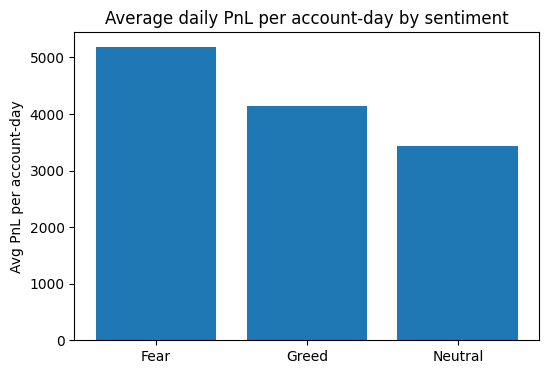

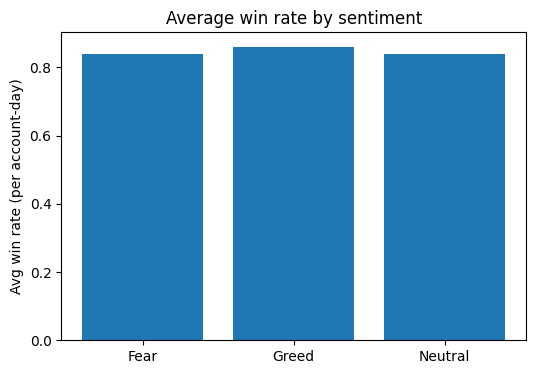

In [16]:
import matplotlib.pyplot as plt

# Focus on Fear vs Greed (and optionally Neutral)
order = ["Fear", "Greed", "Neutral"]
perf_plot = perf_by_sent.loc[order]

plt.figure(figsize=(6,4))
plt.bar(perf_plot.index, perf_plot["avg_pnl_per_account_day"])
plt.ylabel("Avg PnL per account-day")
plt.title("Average daily PnL per account-day by sentiment")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(perf_plot.index, perf_plot["avg_win_rate"])
plt.ylabel("Avg win rate (per account-day)")
plt.title("Average win rate by sentiment")
plt.show()

In [17]:
behav_by_sent = (
    daily_market
    .groupby("sentiment_group")
    .agg(
        days                  = ("trade_date", "nunique"),
        avg_trades_per_day    = ("trades_count", "mean"),
        avg_accounts_per_day  = ("accounts_active", "mean"),
    )
    .round(2)
)

behav_by_sent

,days,avg_trades_per_day,avg_accounts_per_day
sentiment_group,,,
Fear,105,792.73,7.52
Greed,307,294.12,3.82
Neutral,67,562.48,5.61


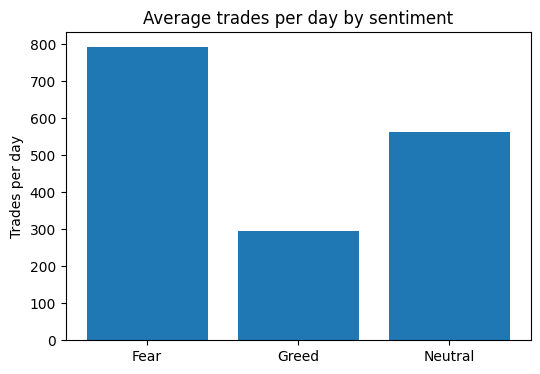

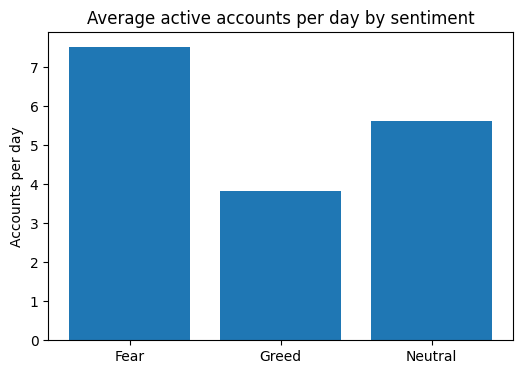

In [18]:
order = ["Fear", "Greed", "Neutral"]
b = behav_by_sent.loc[order]

plt.figure(figsize=(6,4))
plt.bar(b.index, b["avg_trades_per_day"])
plt.ylabel("Trades per day")
plt.title("Average trades per day by sentiment")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(b.index, b["avg_accounts_per_day"])
plt.ylabel("Accounts per day")
plt.title("Average active accounts per day by sentiment")
plt.show()

In [19]:
ls_by_sent = (
    merged
    .groupby("sentiment_group")
    .agg(
        open_long_count  = ("direction", lambda x: (x.str.lower() == "open long").sum()),
        open_short_count = ("direction", lambda x: (x.str.lower() == "open short").sum()),
    )
)

ls_by_sent["long_short_ratio"] = (
    ls_by_sent["open_long_count"] /
    ls_by_sent["open_short_count"].replace({0: np.nan})
)

ls_by_sent

,open_long_count,open_short_count,long_short_ratio
sentiment_group,,,
Fear,24829,14061,1.765806
Greed,14844,19327,0.768045
Neutral,10222,6353,1.609004


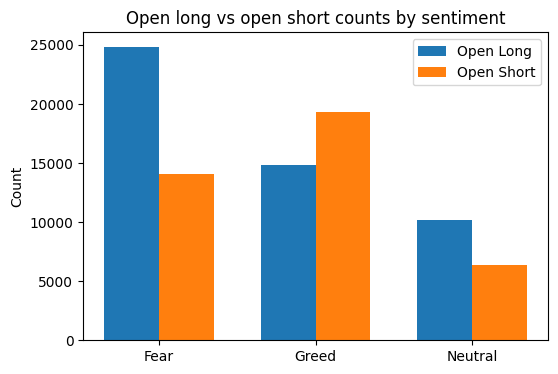

In [20]:
order = ["Fear", "Greed", "Neutral"]
ls_plot = ls_by_sent.loc[order]

plt.figure(figsize=(6,4))
width = 0.35
x = np.arange(len(ls_plot.index))

plt.bar(x - width/2, ls_plot["open_long_count"], width, label="Open Long")
plt.bar(x + width/2, ls_plot["open_short_count"], width, label="Open Short")
plt.xticks(x, ls_plot.index)
plt.ylabel("Count")
plt.title("Open long vs open short counts by sentiment")
plt.legend()
plt.show()

In [21]:
size_by_sent = (
    merged
    .groupby("sentiment_group")["size_usd"]
    .describe()[["count", "mean", "50%", "75%", "max"]]
    .rename(columns={"50%": "median"})
    .round(2)
)

size_by_sent

,count,mean,median,75%,max
sentiment_group,,,,,
Fear,83237.0,7182.01,749.40,2478.71,3921430.72
Greed,90295.0,4574.42,552.20,2000.11,2227114.71
Neutral,37686.0,4782.73,547.66,1994.20,3641180.84


<Figure size 600x400 with 0 Axes>

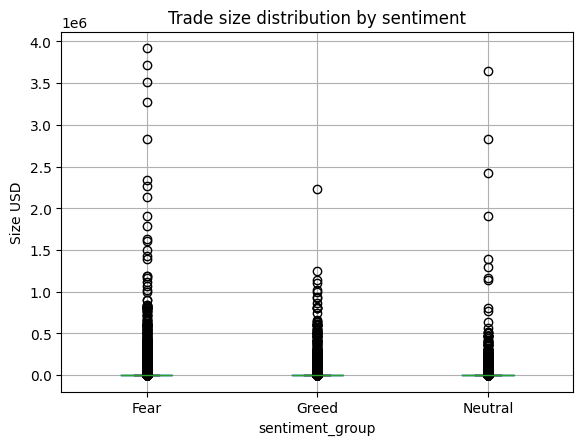

In [22]:
plt.figure(figsize=(6,4))
merged.boxplot(column="size_usd", by="sentiment_group")
plt.suptitle("")
plt.title("Trade size distribution by sentiment")
plt.ylabel("Size USD")
plt.show()

In [23]:
per_account = (
    daily_account
    .groupby("account")
    .agg(
        days_active          = ("trade_date", "nunique"),
        total_trades         = ("trades_count", "sum"),
        avg_trades_per_day   = ("trades_count", "mean"),
        total_pnl            = ("pnl_sum", "sum"),
        mean_daily_pnl       = ("pnl_sum", "mean"),
        pnl_std              = ("pnl_sum", "std"),
        profitable_days      = ("pnl_sum", lambda x: (x > 0).sum()),
        loss_days            = ("pnl_sum", lambda x: (x < 0).sum()),
        avg_daily_size_usd   = ("size_usd_sum", "mean"),
    )
)

per_account["win_day_rate"] = (
    per_account["profitable_days"] /
    (per_account["profitable_days"] + per_account["loss_days"])
)

per_account.head()

,days_active,total_trades,avg_trades_per_day,total_pnl,mean_daily_pnl,pnl_std,profitable_days,loss_days,avg_daily_size_usd,win_day_rate
account,,,,,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,24,3818,159.083333,1.600230e+06,66676.242499,150401.797346,16,3,2.570719e+06,0.842105
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,52,7280,140.000000,4.788532e+04,920.871548,3603.042291,29,10,2.314517e+05,0.743590
0x271b280974205ca63b716753467d5a371de622ab,12,3809,317.416667,-7.043619e+04,-5869.682610,33420.410014,8,3,2.822787e+06,0.727273
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,162,13311,82.166667,1.324648e+05,817.684040,2993.284702,144,14,4.171001e+04,0.911392
0x2c229d22b100a7beb69122eed721cee9b24011dd,69,3239,46.942029,1.686580e+05,2444.318913,4867.743469,54,15,1.473461e+05,0.782609


In [24]:
trade_median = per_account["avg_trades_per_day"].median()
size_median  = per_account["avg_daily_size_usd"].median()
win_med      = per_account["win_day_rate"].median()

per_account["frequency_segment"] = pd.cut(
    per_account["avg_trades_per_day"],
    bins=[-np.inf, trade_median, np.inf],
    labels=["LowFreq", "HighFreq"]
)
per_account["size_segment"] = pd.cut(
    per_account["avg_daily_size_usd"],
    bins=[-np.inf, size_median, np.inf],
    labels=["LowSize", "HighSize"]
)
per_account["consistency_segment"] = pd.cut(
    per_account["win_day_rate"],
    bins=[-np.inf, win_med, np.inf],
    labels=["Inconsistent", "Consistent"]
)

per_account[["avg_trades_per_day", "avg_daily_size_usd", "win_day_rate",
             "frequency_segment", "size_segment", "consistency_segment"]].head()

,avg_trades_per_day,avg_daily_size_usd,win_day_rate,frequency_segment,size_segment,consistency_segment
account,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,159.083333,2.570719e+06,0.842105,HighFreq,HighSize,Inconsistent
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,140.000000,2.314517e+05,0.743590,HighFreq,HighSize,Inconsistent
0x271b280974205ca63b716753467d5a371de622ab,317.416667,2.822787e+06,0.727273,HighFreq,HighSize,Inconsistent
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,82.166667,4.171001e+04,0.911392,HighFreq,LowSize,Consistent
0x2c229d22b100a7beb69122eed721cee9b24011dd,46.942029,1.473461e+05,0.782609,LowFreq,LowSize,Inconsistent


In [25]:
segmented_daily = daily_account.merge(
    per_account[["avg_trades_per_day", "avg_daily_size_usd", "win_day_rate",
                 "frequency_segment", "size_segment", "consistency_segment"]],
    left_on="account", right_index=True, how="left"
)
segmented_daily.head()

,trade_date,account,sentiment_group,trades_count,pnl_sum,pnl_mean,wins,losses,size_usd_sum,size_usd_mean,win_rate,avg_trades_per_day,avg_daily_size_usd,win_day_rate,frequency_segment,size_segment,consistency_segment
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,3,0.000000,0.000000,0,0,477.00,159.000000,NaN,18.953488,32788.418605,0.666667,LowFreq,LowSize,Inconsistent
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,9,0.000000,0.000000,0,0,50005.83,5556.203333,NaN,57.550781,220873.301680,0.805195,LowFreq,LowSize,Inconsistent
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,11,-205.434737,-18.675885,4,2,113203.35,10291.213636,0.666667,57.550781,220873.301680,0.805195,LowFreq,LowSize,Inconsistent
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,2,-24.632034,-12.316017,0,2,10609.95,5304.975000,0.000000,57.550781,220873.301680,0.805195,LowFreq,LowSize,Inconsistent
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,3,0.000000,0.000000,0,0,15348.77,5116.256667,NaN,57.550781,220873.301680,0.805195,LowFreq,LowSize,Inconsistent


In [26]:
freq_sent = (
    segmented_daily
    .groupby(["sentiment_group", "frequency_segment"])
    .agg(
        account_days               = ("account", "count"),
        avg_trades_per_account_day = ("trades_count", "mean"),
        avg_pnl_per_account_day    = ("pnl_sum", "mean"),
    )
    .round(2)
)

freq_sent

/var/folders/yw/4_pls85515dcqxj_f3w2c1r80000gn/T/ipykernel_2270/4241853042.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sentiment_group", "frequency_segment"])


account_days  avg_trades_per_account_day  \
sentiment_group frequency_segment                                             
Fear            LowFreq                     403                       33.81   
                HighFreq                    387                      179.88   
Greed           LowFreq                     693                       38.53   
                HighFreq                    481                      132.22   
Neutral         LowFreq                     210                       45.64   
                HighFreq                    166                      169.28   

                                   avg_pnl_per_account_day  
sentiment_group frequency_segment                           
Fear            LowFreq                            2524.84  
                HighFreq                           7955.44  
Greed           LowFreq                            3590.23  
                HighFreq                           4942.35  
Neutral         LowFreq                            2891.88  
                HighFreq                           4130.28

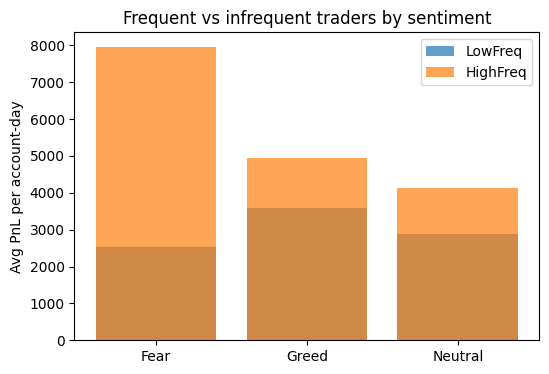

In [27]:
freq_plot = freq_sent.reset_index()
plt.figure(figsize=(6,4))
for seg in ["LowFreq", "HighFreq"]:
    subset = freq_plot[freq_plot["frequency_segment"] == seg]
    plt.bar(subset["sentiment_group"],
            subset["avg_pnl_per_account_day"],
            alpha=0.7,
            label=seg)
plt.ylabel("Avg PnL per account-day")
plt.title("Frequent vs infrequent traders by sentiment")
plt.legend()
plt.show()

In [28]:
size_sent = (
    segmented_daily
    .groupby(["sentiment_group", "size_segment"])
    .agg(
        account_days               = ("account", "count"),
        avg_trades_per_account_day = ("trades_count", "mean"),
        avg_pnl_per_account_day    = ("pnl_sum", "mean"),
    )
    .round(2)
)

size_sent

/var/folders/yw/4_pls85515dcqxj_f3w2c1r80000gn/T/ipykernel_2270/3614857880.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sentiment_group", "size_segment"])


account_days  avg_trades_per_account_day  \
sentiment_group size_segment                                             
Fear            LowSize                424                       37.79   
                HighSize               366                      183.64   
Greed           LowSize                737                       66.40   
                HighSize               437                       94.64   
Neutral         LowSize                219                       56.57   
                HighSize               157                      161.13   

                              avg_pnl_per_account_day  
sentiment_group size_segment                           
Fear            LowSize                       1762.04  
                HighSize                      9150.72  
Greed           LowSize                       3692.43  
                HighSize                      4906.13  
Neutral         LowSize                       2961.80  
                HighSize                      4103.74

In [30]:
cons_sent = (
    segmented_daily
    .groupby(["sentiment_group", "consistency_segment"])
    .agg(
        account_days               = ("account", "count"),
        avg_trades_per_account_day = ("trades_count", "mean"),
        avg_pnl_per_account_day    = ("pnl_sum", "mean"),
    )
    .round(2)
)

cons_sent

/var/folders/yw/4_pls85515dcqxj_f3w2c1r80000gn/T/ipykernel_2270/3877283792.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sentiment_group", "consistency_segment"])


account_days  avg_trades_per_account_day  \
sentiment_group consistency_segment                                             
Fear            Inconsistent                  408                      109.10   
                Consistent                    382                      101.37   
Greed           Inconsistent                  524                       76.98   
                Consistent                    650                       76.86   
Neutral         Inconsistent                  180                       95.45   
                Consistent                    196                      104.62   

                                     avg_pnl_per_account_day  
sentiment_group consistency_segment                           
Fear            Inconsistent                         5327.21  
                Consistent                           5033.41  
Greed           Inconsistent                         5831.54  
                Consistent                           2783.96  
Neutral         Inconsistent                         3016.97  
                Consistent                           3825.85

Insights:

Fear days show higher average PnL per account-day than Greed days, but the 10th-percentile PnL is more negative, indicating that traders face both higher upside and deeper drawdowns during Fear.

Trade frequency and number of active accounts peak on Fear days, while Greed days have the lowest activity, suggesting that volatility and fear attract more trading participation.

High-frequency and high-size traders earn significantly more PnL per account-day on Fear days than low-frequency/low-size traders, implying that aggressive, active strategies capture most of the edge in fearful markets.

Strategy idea 1 – Aggressive segment on Fear days
Target segment: High-frequency, high-size traders (above-median trades/day and USD size). You already defined these from per_account using medians.

Empirical pattern to reference:
1. High-size and high-frequency accounts earn much higher average PnL per account-day, especially on Fear days, compared to low-size/low-frequency accounts.
2. Fear days also show a worse 10th-percentile PnL (“bad day” proxy) than Greed, i.e., more upside and more downside.

Rule of thumb (you can phrase in your report like this):
For high-frequency, high-size traders:
1. On Fear days, it is worth leaning into volatility (keep trade frequency and notional relatively high), but enforce strict risk caps:
2. Allow normal or slightly higher trade frequency and position size when sentiment_group == Fear.
3. Impose a tighter per-day loss limit and closer stop-loss distances on Fear days to control the fatter downside tail.
4. On Greed days, lower max position size and leverage, because the edge per account-day is smaller and drawdowns do not justify aggressive scaling.

This connects directly to higher avg PnL per account-day for Fear vs Greed, but more negative lower-tail PnL on Fear days.

Strategy idea 2 – Conservative segment on Greed/Neutral days
Target segment: Low-frequency, low-size traders (below-median trades/day and USD size).

Empirical pattern to reference:
1. Low-frequency/low-size traders gain much less from Fear days compared with the aggressive cohort, while still being exposed to the same bad-tail environment.
2. Greed and Neutral days offer moderate average PnL with milder drawdowns (p10 PnL closer to or at zero) compared to Fear.

Rule of thumb:
For low-frequency, low-size (more conservative) traders:
1. Prioritize opening new positions on Greed and Neutral days, where drawdowns are milder and average PnL per trade is higher.
2. On Fear days, reduce both trade frequency and position size (or even sit out entirely unless a very clear setup exists).
3. Avoid “hero trades” against extreme sentiment on Fear days; keep leverage modest and focus on risk preservation.

You can state this explicitly as an “if/else” policy in your write-up:
  if sentiment_group == "Fear": max_trades_per_day = small; max_size = small
  if sentiment_group in {"Greed", "Neutral"}: use normal limits

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

df = daily_account.copy()

# Target: was this account profitable on this day?
df["profitable"] = (df["pnl_sum"] > 0).astype(int)

# Basic features from the *same* day
# (for next-day prediction, you will lag them later)
features = [
    "trades_count",
    "pnl_sum",
    "win_rate",
    "size_usd_sum",
    "size_usd_mean",
]

# One-hot encode sentiment_group
df = pd.get_dummies(df, columns=["sentiment_group"], drop_first=True)
df.head()

# Sort so shifting makes sense
df = df.sort_values(["account", "trade_date"])

# Group by account and lag features by 1 day
for col in features + [c for c in df.columns if c.startswith("sentiment_group_")]:
    df[f"{col}_lag1"] = df.groupby("account")[col].shift(1)

# Drop rows where lag is NaN (first day per account)
model_df = df.dropna(subset=[f"{col}_lag1" for col in features])

X_cols = [c for c in model_df.columns if c.endswith("_lag1")]
y = model_df["profitable"]
X = model_df[X_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

AUC: 0.5796504677508112
              precision    recall  f1-score   support

           0       0.38      0.02      0.04       151
           1       0.70      0.99      0.82       349

    accuracy                           0.69       500
   macro avg       0.54      0.50      0.43       500
weighted avg       0.60      0.69      0.58       500



In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feat_cols = [
    "avg_trades_per_day",
    "avg_daily_size_usd",
    "win_day_rate",
    "pnl_std",          # volatility of daily PnL
]

cluster_df = per_account[feat_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

per_account["cluster"] = -1
per_account.loc[cluster_df.index, "cluster"] = labels

per_account.groupby("cluster")[feat_cols].mean().round(2)

cluster_perf = (
    daily_account
    .merge(per_account[["cluster"]], left_on="account", right_index=True, how="left")
    .groupby(["cluster", "sentiment_group"])
    .agg(avg_pnl_per_account_day=("pnl_sum", "mean"))
    .round(2)
)

cluster_perf


avg_pnl_per_account_day
cluster sentiment_group                         
0       Fear                             2258.46
        Greed                            3588.71
        Neutral                          2398.12
1       Fear                             2399.38
        Greed                            8105.97
        Neutral                         -5088.06
2       Fear                            47391.72
        Greed                           16645.39
        Neutral                         35271.84